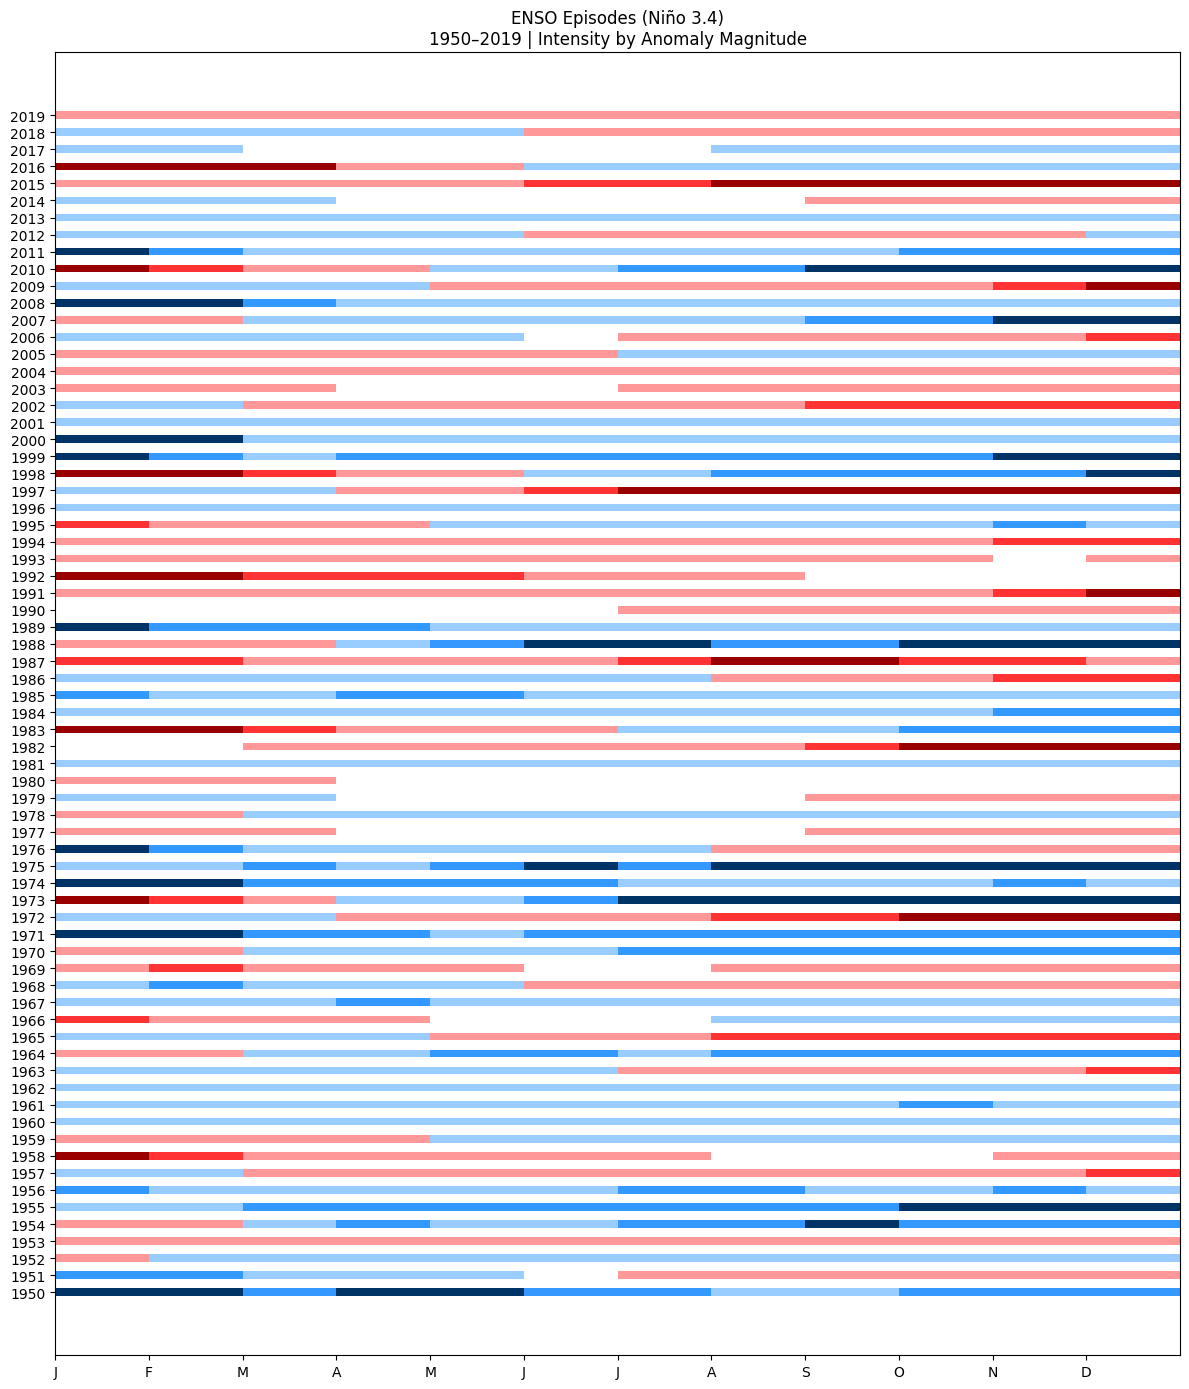

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Filtrar intervalo 1950–2019
# ============================================================

df = df[(df["Year"] >= 1950) & (df["Year"] <= 2019)].reset_index(drop=True)

years = sorted(df["Year"].unique())

fig, ax = plt.subplots(figsize=(12, 14))

spacing = 1.8
bar_height = 0.8

# ============================================================
# Función de color según magnitud de anomalía
# ============================================================

def get_color_from_anomaly(anom):

    # Niño (positivo)
    if anom > 0:
        if anom < 1.0:
            return "#ff9999"   # rojo claro
        elif anom < 1.5:
            return "#ff3333"   # rojo medio
        else:
            return "#990000"   # rojo oscuro

    # Niña (negativo)
    elif anom < 0:
        if anom > -1.0:
            return "#99ccff"   # azul claro
        elif anom > -1.5:
            return "#3399ff"   # azul medio
        else:
            return "#003366"   # azul oscuro

    return None

# ============================================================
# Dibujar meses que pertenezcan a eventos válidos
# ============================================================

for i in range(len(df)):

    if df.loc[i, "Event"] != 0:  # solo meses dentro de evento persistente

        year = df.loc[i, "Year"]
        month = int(df.loc[i, "Month"]) - 1
        anom = df.loc[i, "Anomaly"]

        color = get_color_from_anomaly(anom)

        y_pos = years.index(year) * spacing

        ax.barh(y_pos, 1,
                left=month,
                height=bar_height,
                color=color)

# ============================================================
# Ajustes ejes
# ============================================================

ax.set_yticks(np.arange(len(years)) * spacing)
ax.set_yticklabels(years)

ax.set_xticks(np.arange(12))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])

ax.set_xlim(0, 12)
ax.set_title("ENSO Episodes (Niño 3.4)\n1950–2019 | Intensity by Anomaly Magnitude")

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np

# ============================================================
# 1. Cargar datos
# ============================================================

file_path = "datos niño.xlsx"
df = pd.read_excel(file_path)

# Tomar YR, MON y última columna (ANOM de NINO3.4)
df = df.iloc[:, [0, 1, -1]]
df.columns = ["Year", "Month", "Anomaly"]

# Ordenar cronológicamente
df = df.sort_values(["Year", "Month"]).reset_index(drop=True)

# ============================================================
# 2. Clasificar fase por signo
# ============================================================

df["Phase"] = np.where(df["Anomaly"] > 0, 1,
                np.where(df["Anomaly"] < 0, -1, 0))

# ============================================================
# 3. Detectar persistencia ≥ 6 meses consecutivos
# ============================================================

df["Event"] = 0

current_phase = 0
count = 0
start_idx = 0

for i in range(len(df)):
    phase = df.loc[i, "Phase"]

    if phase == current_phase and phase != 0:
        count += 1
    else:
        if count >= 6 and current_phase != 0:
            df.loc[start_idx:i-1, "Event"] = current_phase

        current_phase = phase
        count = 1 if phase != 0 else 0
        start_idx = i

# Verificar último bloque
if count >= 6 and current_phase != 0:
    df.loc[start_idx:len(df)-1, "Event"] = current_phase

# ============================================================
# 4. Limitar conteo hasta 2019
# (sin afectar la detección de persistencia)
# ============================================================

df_count = df[df["Year"] <= 2019].copy()

# ============================================================
# 5. Contar eventos por año
# ============================================================

summary = []

for year in sorted(df_count["Year"].unique()):
    year_data = df_count[df_count["Year"] == year]

    eventos_nino = 0
    eventos_nina = 0

    prev = 0
    for val in year_data["Event"]:
        if val == 1 and prev != 1:
            eventos_nino += 1
        if val == -1 and prev != -1:
            eventos_nina += 1
        prev = val

    summary.append([year, eventos_nino, eventos_nina])

summary_df = pd.DataFrame(summary, columns=["Year", "Niños", "Niñas"])

# ============================================================
# 6. Mostrar resultados
# ============================================================

print("\nResumen por año (hasta 2019):")
print(summary_df)

print("\nTotal histórico hasta 2019:")
print("Total Niños:", summary_df["Niños"].sum())
print("Total Niñas:", summary_df["Niñas"].sum())

# ============================================================
# 7. Guardar a Excel
# ============================================================

output_file = "conteo_ENSO_por_año.xlsx"
summary_df.to_excel(output_file, index=False)

print(f"\nArchivo guardado como: {output_file}")


Resumen por año (hasta 2019):
    Year  Niños  Niñas
0   1950      0      1
1   1951      1      1
2   1952      1      1
3   1953      1      0
4   1954      1      1
..   ...    ...    ...
65  2015      1      0
66  2016      1      1
67  2017      0      2
68  2018      1      1
69  2019      1      0

[70 rows x 3 columns]

Total histórico hasta 2019:
Total Niños: 53
Total Niñas: 56

Archivo guardado como: conteo_ENSO_por_año.xlsx
